In [1]:
import torch
import numpy as np
from torch.utils.data import Dataset,DataLoader
import matplotlib.pyplot as plt
import torch.nn.functional as F
import seaborn as sns
from tqdm import tqdm
import matplotlib.pyplot as plt
from Models import *
from DDBSCAN import Raster_DBSCAN
import matplotlib.colors as mcolors
import cv2
from collections import defaultdict
import pandas as pd
from scipy import stats
import seaborn as sns
from filterpy.kalman import KalmanFilter
from scipy.optimize import linear_sum_assignment
from filterpy.common import Q_discrete_white_noise
from Utils import *
import os
from SocialLSTM.ModelSocial import LaneSocialLSTM
# times new roman font
plt.rcParams["font.family"] = "Times New Roman"
seed = 414
# np.random.seed(seed)
colors = np.random.rand(600, 3)
colors = np.concatenate([np.array([[0,0,0]]),colors],axis = 0)
colormap = mcolors.ListedColormap(colors)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


## Encoder Decoder LSTM Evaluation Results

In [119]:
lane_unit = 200
time_span = 100
hidden_size = 256
num_layers = 2
input_size = lane_unit
learning_rate = 0.001
num_epochs = 50
dir_img = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\images'
traj_dir = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\labels'
# raw_time_space_diagram = np.load(r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\lane_2.npy')
img_out_folder = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\pred_out'
time_span = 100
lane_unit_num = 200
x_error_threshold = 4
best_model = BidirectionalLSTMLaneReconstructor(input_size, hidden_size, num_layers).to(device)
mocel_save_path = r"D:\TimeSpaceDiagramDataset\EncoderDecoder_EvenlySampled_FreeflowAug_0914_5res_lanechange_signal\models\train_2"
if not os.path.exists(mocel_save_path):
    os.makedirs(mocel_save_path)
model_name = f'checkpoint_16.pth'
best_model.load_state_dict(torch.load(os.path.join(mocel_save_path, model_name),weights_only=False))
best_model.eval()
# db = Raster_DBSCAN(Td_map_szie=(lane_unit,time_span), window_size=[9,15],eps = 1,min_samples=1)

BidirectionalLSTMLaneReconstructor(
  (encoder): LSTM(200, 256, num_layers=2, batch_first=True, bidirectional=True)
  (decoder): LSTM(512, 512, num_layers=2, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (output_layer): Linear(in_features=512, out_features=200, bias=True)
  (sigmoid): Sigmoid()
)

In [32]:
dir_img = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\images'
traj_dir = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\labels'
# raw_time_space_diagram = np.load(r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\lane_2.npy')
img_out_folder = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\pred_out'
time_span = 100
lane_unit_num = 200
x_error_threshold = 4
db = Raster_DBSCAN(Td_map_szie=(lane_unit,time_span), window_size=[11,19],eps = 1,min_samples=3)

time_space_diagram_list = os.listdir(dir_img)
trajectory_list = os.listdir(traj_dir)
Iou_threshold = 0.8
total_tps, total_fps, total_fns = [], [], []
total_discontinuities, total_switches = [], []
total_speed_errors, total_spatial_errors = [], []
total_recovered_trajs = []
for conf_thred in np.arange(0.2,0.9,0.05):
    total_tp, total_fp, total_fn = 0, 0, 0
    total_switch,total_discontinuity = 0,0
    recovered_traj = 0
    for frame_ind in tqdm(range(len(time_space_diagram_list))):
        time_space_diagram_name = time_space_diagram_list[frame_ind]
        trajectory_name = trajectory_list[frame_ind]
        time_space_diagram_raw = cv2.imread(os.path.join(dir_img,time_space_diagram_name), cv2.IMREAD_GRAYSCALE)

        traj_type_label,trajs_label = get_traj_labels(traj_dir,trajectory_name,time_space_diagram_raw)

        time_space_diagram_input = time_space_diagram_raw > 100
        time_space_diagram_input = time_space_diagram_input.astype(np.uint8)
        original_shape = time_space_diagram_input.shape
        padding = np.zeros((lane_unit_num - time_space_diagram_input.shape[0], time_space_diagram_input.shape[1]))
        time_space_diagram_input = np.concatenate((time_space_diagram_input,padding), axis=0)
        
        with torch.no_grad():
            input_snippet = torch.from_numpy(time_space_diagram_input).float().to(device)
            input_snippet = input_snippet.unsqueeze(0)
            output = best_model(input_snippet)
            output = output.squeeze(0).cpu().numpy()
        output[125:] = 0
        trajs_pred = get_trajs_from_LSTM_out(output,db,conf_thred = conf_thred,time_span = 100, lane_unit = 200)
        if len(trajs_pred) == 0:
            total_fn += len(trajs_label)
            continue
        TrajIoUMatrix,TrajPortionMatrix = get_TrajIoU(trajs_label,trajs_pred,x_error_threshold = x_error_threshold)
        tp,fp,fn,id_switch,discontinuity = get_accuracy_metric(Iou_threshold, TrajIoUMatrix, TrajPortionMatrix, trajs_pred)
        
        pred_index = TrajIoUMatrix.argmax(axis = 1)
        pred_IoU = TrajIoUMatrix.max(axis = 1)
        speed_errors,spatial_errors,occ_speed_errors,occ_spatial_errors,acceleration_errors,occ_acceleration_errors = get_speed_spatial_error(trajs_label,trajs_pred,pred_index,pred_IoU,Iou_threshold,speed_eva_window,traj_type_label)

        total_tp += tp
        total_fp += fp
        total_fn += fn
        total_switch += id_switch
        total_discontinuity += discontinuity
        total_speed_errors.append(speed_errors)
        total_spatial_errors.append(spatial_errors)
        
        trajs_label = [traj for i, traj in enumerate(trajs_label) if traj_type_label[i] == 0] # for only occlusion evaluation


        TrajIoUMatrix,TrajPortionMatrix = get_TrajIoU(trajs_label,trajs_pred,x_error_threshold = x_error_threshold)
        tp,fp,fn,id_switch,discontinuity = get_accuracy_metric(Iou_threshold, TrajIoUMatrix, TrajPortionMatrix, trajs_pred)
        recovered_traj += tp
    
    total_tps.append(total_tp)
    total_fps.append(total_fp)
    total_fns.append(total_fn)
    total_switches.append(total_switch)
    total_discontinuities.append(total_discontinuity)
    total_recovered_trajs.append(recovered_traj)

df = pd.DataFrame({'ConfThred':np.arange(0.2,0.9,0.05),'TP':total_tps,'FP':total_fps,'FN':total_fns, 'IDSwitch':total_switches,'Discontinuity':total_discontinuities,'RecoveredTrajs':total_recovered_trajs})
df['precision'] = df['TP'] / (df['TP'] + df['FP'])
df['recall'] = df['TP'] / (df['TP'] + df['FN'])
df['F1'] = 2 * df['precision'] * df['recall'] / (df['precision'] + df['recall'])

100%|██████████| 325/325 [00:11<00:00, 29.37it/s]


In [35]:
df # encode-decoder 256 confidence threshold 0.2-0.9

,ConfThred,TP,FP,FN,IDSwitch,Discontinuity,RecoveredTrajs,precision,recall,F1
0,0.20,1361,146,117,33,11,507,0.903119,0.920839,0.911893
1,0.25,1390,105,88,29,11,515,0.929766,0.940460,0.935082
2,0.30,1422,104,56,24,13,521,0.931848,0.962111,0.946738
3,0.35,1435,97,43,19,15,527,0.936684,0.970907,0.953488
4,0.40,1443,104,35,11,29,530,0.932773,0.976319,0.954050
5,0.45,1448,171,30,6,76,535,0.894379,0.979702,0.935098
6,0.50,1456,267,22,2,151,538,0.845038,0.985115,0.909716
7,0.55,1449,319,29,1,220,536,0.819570,0.980379,0.892791
8,0.60,1419,397,59,1,287,529,0.781388,0.960081,0.861566
9,0.65,1373,443,105,1,325,523,0.756057,0.928958,0.833637


# LSTM att Encoder Decoder

In [2]:

lane_unit = 200
time_span = 100
hidden_size = 256
num_layers = 2
input_size = lane_unit
learning_rate = 0.001
num_epochs = 50
dir_img = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\images'
traj_dir = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\labels'
# raw_time_space_diagram = np.load(r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\lane_2.npy')
img_out_folder = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\pred_out'
time_span = 100
lane_unit_num = 200
x_error_threshold = 4
best_model = BidirectionalLSTMLaneReconstructorWithAttention(input_size, hidden_size, num_layers).to(device)
mocel_save_path = r"D:\TimeSpaceDiagramDataset\LSTM_att_256_EncoderDecoder_EvenlySampled_FreeflowAug_0416_5res_lanechange_signal\models\train_0"
if not os.path.exists(mocel_save_path):
    os.makedirs(mocel_save_path)
model_name = f'checkpoint_8.pth'
best_model.load_state_dict(torch.load(os.path.join(mocel_save_path, model_name),weights_only=False))
best_model.eval()
# db = Raster_DBSCAN(Td_map_szie=(lane_unit,time_span), window_size=[9,15],eps = 1,min_samples=1)

BidirectionalLSTMLaneReconstructorWithAttention(
  (encoder): LSTM(200, 256, num_layers=2, batch_first=True, bidirectional=True)
  (attention): AttentionModule(
    (attention): Linear(in_features=512, out_features=1, bias=True)
  )
  (decoder): LSTM(1024, 512, num_layers=2, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (output_layer): Linear(in_features=512, out_features=200, bias=True)
  (sigmoid): Sigmoid()
)

In [3]:
dir_img = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\images'
traj_dir = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\labels'
# raw_time_space_diagram = np.load(r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\lane_2.npy')
img_out_folder = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\pred_out'
time_span = 100
lane_unit_num = 200
x_error_threshold = 4
db = Raster_DBSCAN(Td_map_szie=(lane_unit,time_span), window_size=[11,19],eps = 1,min_samples=3)

time_space_diagram_list = os.listdir(dir_img)
trajectory_list = os.listdir(traj_dir)
Iou_threshold = 0.8
total_tps, total_fps, total_fns = [], [], []
total_discontinuities, total_switches = [], []
total_speed_errors, total_spatial_errors = [], []
total_recovered_trajs = []
for conf_thred in np.arange(0.2,0.9,0.05):
    total_tp, total_fp, total_fn = 0, 0, 0
    total_switch,total_discontinuity = 0,0
    recovered_traj = 0
    for frame_ind in tqdm(range(len(time_space_diagram_list))):
        time_space_diagram_name = time_space_diagram_list[frame_ind]
        trajectory_name = trajectory_list[frame_ind]
        time_space_diagram_raw = cv2.imread(os.path.join(dir_img,time_space_diagram_name), cv2.IMREAD_GRAYSCALE)

        traj_type_label,trajs_label = get_traj_labels(traj_dir,trajectory_name,time_space_diagram_raw)

        time_space_diagram_input = time_space_diagram_raw > 100
        time_space_diagram_input = time_space_diagram_input.astype(np.uint8)
        original_shape = time_space_diagram_input.shape
        padding = np.zeros((lane_unit_num - time_space_diagram_input.shape[0], time_space_diagram_input.shape[1]))
        time_space_diagram_input = np.concatenate((time_space_diagram_input,padding), axis=0)
        
        with torch.no_grad():
            input_snippet = torch.from_numpy(time_space_diagram_input).float().to(device)
            input_snippet = input_snippet.unsqueeze(0)
            output = best_model(input_snippet)
            output = output.squeeze(0).cpu().numpy()
        output[125:] = 0
        trajs_pred = get_trajs_from_LSTM_out(output,db,conf_thred = conf_thred,time_span = 100, lane_unit = 200)
        if len(trajs_pred) == 0:
            total_fn += len(trajs_label)
            continue
        TrajIoUMatrix,TrajPortionMatrix = get_TrajIoU(trajs_label,trajs_pred,x_error_threshold = x_error_threshold)
        tp,fp,fn,id_switch,discontinuity = get_accuracy_metric(Iou_threshold, TrajIoUMatrix, TrajPortionMatrix, trajs_pred)
        
        pred_index = TrajIoUMatrix.argmax(axis = 1)
        pred_IoU = TrajIoUMatrix.max(axis = 1)
        speed_errors,spatial_errors,occ_speed_errors,occ_spatial_errors,acceleration_errors,occ_acceleration_errors = get_speed_spatial_error(trajs_label,trajs_pred,pred_index,pred_IoU,Iou_threshold,speed_eva_window,traj_type_label)

        total_tp += tp
        total_fp += fp
        total_fn += fn
        total_switch += id_switch
        total_discontinuity += discontinuity
        total_speed_errors.append(speed_errors)
        total_spatial_errors.append(spatial_errors)
        
        trajs_label = [traj for i, traj in enumerate(trajs_label) if traj_type_label[i] == 0] # for only occlusion evaluation


        TrajIoUMatrix,TrajPortionMatrix = get_TrajIoU(trajs_label,trajs_pred,x_error_threshold = x_error_threshold)
        tp,fp,fn,id_switch,discontinuity = get_accuracy_metric(Iou_threshold, TrajIoUMatrix, TrajPortionMatrix, trajs_pred)
        recovered_traj += tp
    
    total_tps.append(total_tp)
    total_fps.append(total_fp)
    total_fns.append(total_fn)
    total_switches.append(total_switch)
    total_discontinuities.append(total_discontinuity)
    total_recovered_trajs.append(recovered_traj)

df = pd.DataFrame({'ConfThred':np.arange(0.2,0.9,0.05),'TP':total_tps,'FP':total_fps,'FN':total_fns, 'IDSwitch':total_switches,'Discontinuity':total_discontinuities,'RecoveredTrajs':total_recovered_trajs})
df['precision'] = df['TP'] / (df['TP'] + df['FP'])
df['recall'] = df['TP'] / (df['TP'] + df['FN'])
df['F1'] = 2 * df['precision'] * df['recall'] / (df['precision'] + df['recall'])

  6%|▌         | 20/325 [00:03<00:44,  6.79it/s]c:\Users\zhChe\anaconda3\envs\tracking3\lib\site-packages\scipy\interpolate\_interpolate.py:698: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
100%|██████████| 325/325 [00:45<00:00,  7.18it/s]


In [5]:
df

,ConfThred,TP,FP,FN,IDSwitch,Discontinuity,RecoveredTrajs,precision,recall,F1
0,0.20,1320,127,158,40,5,492,0.912232,0.893099,0.902564
1,0.25,1371,101,107,33,4,509,0.931386,0.927605,0.929492
2,0.30,1398,97,80,25,7,516,0.935117,0.945873,0.940464
3,0.35,1427,99,51,17,14,523,0.935125,0.965494,0.950067
4,0.40,1448,103,30,10,29,536,0.933591,0.979702,0.956091
5,0.45,1460,174,18,2,73,542,0.893513,0.987821,0.938303
6,0.50,1458,267,20,2,151,542,0.845217,0.986468,0.910397
7,0.55,1431,330,47,1,228,534,0.812606,0.968200,0.883606
8,0.60,1381,405,97,1,280,523,0.773236,0.934371,0.846201
9,0.65,1311,473,167,1,341,511,0.734865,0.887009,0.803801


## RNN


In [ ]:

lane_unit = 200
time_span = 100
hidden_size = 256
num_layers = 2
input_size = lane_unit
learning_rate = 0.001
num_epochs = 50
best_model = BidirectionalRNNLaneReconstructor(input_size, hidden_size, num_layers).to(device)
mocel_save_path = r"D:\TimeSpaceDiagramDataset\RNN_256_EncoderDecoder_EvenlySampled_FreeflowAug_0402_5res_lanechange_signal\models\train_0"
if not os.path.exists(mocel_save_path):
    os.makedirs(mocel_save_path)
model_name = f'checkpoint_16.pth'
best_model.load_state_dict(torch.load(os.path.join(mocel_save_path, model_name),weights_only=False))
best_model.eval()
dir_img = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\images'
traj_dir = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\labels'
# raw_time_space_diagram = np.load(r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\lane_2.npy')
img_out_folder = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\pred_out'
time_span = 100
lane_unit_num = 200
x_error_threshold = 4
db = Raster_DBSCAN(Td_map_szie=(lane_unit,time_span), window_size=[11,19],eps = 1,min_samples=3)

time_space_diagram_list = os.listdir(dir_img)
trajectory_list = os.listdir(traj_dir)
Iou_threshold = 0.8
total_tps, total_fps, total_fns = [], [], []
total_discontinuities, total_switches = [], []
total_speed_errors, total_spatial_errors = [], []
total_recovered_trajs = []
for conf_thred in np.arange(0.2,0.9,0.05):
    total_tp, total_fp, total_fn = 0, 0, 0
    total_switch,total_discontinuity = 0,0
    recovered_traj = 0
    for frame_ind in tqdm(range(len(time_space_diagram_list))):
        time_space_diagram_name = time_space_diagram_list[frame_ind]
        trajectory_name = trajectory_list[frame_ind]
        time_space_diagram_raw = cv2.imread(os.path.join(dir_img,time_space_diagram_name), cv2.IMREAD_GRAYSCALE)

        traj_type_label,trajs_label = get_traj_labels(traj_dir,trajectory_name,time_space_diagram_raw)

        time_space_diagram_input = time_space_diagram_raw > 100
        time_space_diagram_input = time_space_diagram_input.astype(np.uint8)
        original_shape = time_space_diagram_input.shape
        padding = np.zeros((lane_unit_num - time_space_diagram_input.shape[0], time_space_diagram_input.shape[1]))
        time_space_diagram_input = np.concatenate((time_space_diagram_input,padding), axis=0)
        
        with torch.no_grad():
            input_snippet = torch.from_numpy(time_space_diagram_input).float().to(device)
            input_snippet = input_snippet.unsqueeze(0)
            output = best_model(input_snippet)
            output = output.squeeze(0).cpu().numpy()
        output[125:] = 0
        trajs_pred = get_trajs_from_LSTM_out(output,db,conf_thred = conf_thred,time_span = 100, lane_unit = 200)
        if len(trajs_pred) == 0:
            total_fn += len(trajs_label)
            continue
        TrajIoUMatrix,TrajPortionMatrix = get_TrajIoU(trajs_label,trajs_pred,x_error_threshold = x_error_threshold)
        tp,fp,fn,id_switch,discontinuity = get_accuracy_metric(Iou_threshold, TrajIoUMatrix, TrajPortionMatrix, trajs_pred)
        
        pred_index = TrajIoUMatrix.argmax(axis = 1)
        pred_IoU = TrajIoUMatrix.max(axis = 1)
        speed_errors,spatial_errors,occ_speed_errors,occ_spatial_errors,acceleration_errors,occ_acceleration_errors = get_speed_spatial_error(trajs_label,trajs_pred,pred_index,pred_IoU,Iou_threshold,speed_eva_window,traj_type_label)

        total_tp += tp
        total_fp += fp
        total_fn += fn
        total_switch += id_switch
        total_discontinuity += discontinuity
        total_speed_errors.append(speed_errors)
        total_spatial_errors.append(spatial_errors)
        
        trajs_label = [traj for i, traj in enumerate(trajs_label) if traj_type_label[i] == 0] # for only occlusion evaluation
        TrajIoUMatrix,TrajPortionMatrix = get_TrajIoU(trajs_label,trajs_pred,x_error_threshold = x_error_threshold)
        tp,fp,fn,id_switch,discontinuity = get_accuracy_metric(Iou_threshold, TrajIoUMatrix, TrajPortionMatrix, trajs_pred)
        recovered_traj += tp
    
    total_tps.append(total_tp)
    total_fps.append(total_fp)
    total_fns.append(total_fn)
    total_switches.append(total_switch)
    total_discontinuities.append(total_discontinuity)
    total_recovered_trajs.append(recovered_traj)

df = pd.DataFrame({'ConfThred':np.arange(0.2,0.9,0.05),'TP':total_tps,'FP':total_fps,'FN':total_fns, 'IDSwitch':total_switches,'Discontinuity':total_discontinuities,'RecoveredTrajs':total_recovered_trajs})
df['precision'] = df['TP'] / (df['TP'] + df['FP'])
df['recall'] = df['TP'] / (df['TP'] + df['FN'])
df['F1'] = 2 * df['precision'] * df['recall'] / (df['precision'] + df['recall'])

In [47]:

lane_unit = 200
time_span = 100
hidden_size = 128
num_layers = 2
input_size = lane_unit
learning_rate = 0.001
num_epochs = 50
best_model = BidirectionalRNNLaneReconstructor(input_size, hidden_size, num_layers).to(device)
mocel_save_path = r"D:\TimeSpaceDiagramDataset\RNN_128_EncoderDecoder_EvenlySampled_FreeflowAug_0401_5res_lanechange_signal\models\train_0"
if not os.path.exists(mocel_save_path):
    os.makedirs(mocel_save_path)
model_name = f'checkpoint_16.pth'
best_model.load_state_dict(torch.load(os.path.join(mocel_save_path, model_name),weights_only=False))
best_model.eval()
dir_img = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\images'
traj_dir = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\labels'
# raw_time_space_diagram = np.load(r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\lane_2.npy')
img_out_folder = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\pred_out'
time_span = 100
lane_unit_num = 200
x_error_threshold = 4
db = Raster_DBSCAN(Td_map_szie=(lane_unit,time_span), window_size=[11,19],eps = 1,min_samples=3)

time_space_diagram_list = os.listdir(dir_img)
trajectory_list = os.listdir(traj_dir)
Iou_threshold = 0.8
total_tps, total_fps, total_fns = [], [], []
total_discontinuities, total_switches = [], []
total_speed_errors, total_spatial_errors = [], []
total_recovered_trajs = []
for conf_thred in np.arange(0.2,0.9,0.05):
    total_tp, total_fp, total_fn = 0, 0, 0
    total_switch,total_discontinuity = 0,0
    recovered_traj = 0
    for frame_ind in tqdm(range(len(time_space_diagram_list))):
        time_space_diagram_name = time_space_diagram_list[frame_ind]
        trajectory_name = trajectory_list[frame_ind]
        time_space_diagram_raw = cv2.imread(os.path.join(dir_img,time_space_diagram_name), cv2.IMREAD_GRAYSCALE)

        traj_type_label,trajs_label = get_traj_labels(traj_dir,trajectory_name,time_space_diagram_raw)

        time_space_diagram_input = time_space_diagram_raw > 100
        time_space_diagram_input = time_space_diagram_input.astype(np.uint8)
        original_shape = time_space_diagram_input.shape
        padding = np.zeros((lane_unit_num - time_space_diagram_input.shape[0], time_space_diagram_input.shape[1]))
        time_space_diagram_input = np.concatenate((time_space_diagram_input,padding), axis=0)
        
        with torch.no_grad():
            input_snippet = torch.from_numpy(time_space_diagram_input).float().to(device)
            input_snippet = input_snippet.unsqueeze(0)
            output = best_model(input_snippet)
            output = output.squeeze(0).cpu().numpy()
        output[125:] = 0
        trajs_pred = get_trajs_from_LSTM_out(output,db,conf_thred = conf_thred,time_span = 100, lane_unit = 200)
        if len(trajs_pred) == 0:
            total_fn += len(trajs_label)
            continue
        TrajIoUMatrix,TrajPortionMatrix = get_TrajIoU(trajs_label,trajs_pred,x_error_threshold = x_error_threshold)
        tp,fp,fn,id_switch,discontinuity = get_accuracy_metric(Iou_threshold, TrajIoUMatrix, TrajPortionMatrix, trajs_pred)
        
        pred_index = TrajIoUMatrix.argmax(axis = 1)
        pred_IoU = TrajIoUMatrix.max(axis = 1)
        speed_errors,spatial_errors,occ_speed_errors,occ_spatial_errors,acceleration_errors,occ_acceleration_errors = get_speed_spatial_error(trajs_label,trajs_pred,pred_index,pred_IoU,Iou_threshold,speed_eva_window,traj_type_label)

        total_tp += tp
        total_fp += fp
        total_fn += fn
        total_switch += id_switch
        total_discontinuity += discontinuity
        total_speed_errors.append(speed_errors)
        total_spatial_errors.append(spatial_errors)
        
        trajs_label = [traj for i, traj in enumerate(trajs_label) if traj_type_label[i] == 0] # for only occlusion evaluation


        TrajIoUMatrix,TrajPortionMatrix = get_TrajIoU(trajs_label,trajs_pred,x_error_threshold = x_error_threshold)
        tp,fp,fn,id_switch,discontinuity = get_accuracy_metric(Iou_threshold, TrajIoUMatrix, TrajPortionMatrix, trajs_pred)
        recovered_traj += tp
    
    total_tps.append(total_tp)
    total_fps.append(total_fp)
    total_fns.append(total_fn)
    total_switches.append(total_switch)
    total_discontinuities.append(total_discontinuity)
    total_recovered_trajs.append(recovered_traj)

df = pd.DataFrame({'ConfThred':np.arange(0.2,0.9,0.05),'TP':total_tps,'FP':total_fps,'FN':total_fns, 'IDSwitch':total_switches,'Discontinuity':total_discontinuities,'RecoveredTrajs':total_recovered_trajs})
df['precision'] = df['TP'] / (df['TP'] + df['FP'])
df['recall'] = df['TP'] / (df['TP'] + df['FN'])
df['F1'] = 2 * df['precision'] * df['recall'] / (df['precision'] + df['recall'])

 13%|█▎        | 43/325 [00:00<00:06, 46.87it/s]c:\Users\zhChe\anaconda3\envs\tracking3\lib\site-packages\scipy\interpolate\_interpolate.py:698: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
100%|██████████| 325/325 [00:07<00:00, 45.16it/s]


## RNN attention

In [49]:

lane_unit = 200
time_span = 100
hidden_size = 256
num_layers = 2
input_size = lane_unit
learning_rate = 0.001
num_epochs = 50
best_model = BidirectionalRNNLaneReconstructorWithAttention(input_size, hidden_size, num_layers).to(device)
mocel_save_path = r"D:\TimeSpaceDiagramDataset\LSTM_att_256_EncoderDecoder_EvenlySampled_FreeflowAug_0402_5res_lanechange_signal\models\train_1"
if not os.path.exists(mocel_save_path):
    os.makedirs(mocel_save_path)
model_name = f'checkpoint_16.pth'
best_model.load_state_dict(torch.load(os.path.join(mocel_save_path, model_name),weights_only=False))
best_model.eval()
dir_img = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\images'
traj_dir = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\labels'
# raw_time_space_diagram = np.load(r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\lane_2.npy')
img_out_folder = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\pred_out'
time_span = 100
lane_unit_num = 200
x_error_threshold = 4
db = Raster_DBSCAN(Td_map_szie=(lane_unit,time_span), window_size=[11,19],eps = 1,min_samples=3)

time_space_diagram_list = os.listdir(dir_img)
trajectory_list = os.listdir(traj_dir)
Iou_threshold = 0.8
total_tps, total_fps, total_fns = [], [], []
total_discontinuities, total_switches = [], []
total_speed_errors, total_spatial_errors = [], []
total_recovered_trajs = []
for conf_thred in np.arange(0.2,0.9,0.05):
    total_tp, total_fp, total_fn = 0, 0, 0
    total_switch,total_discontinuity = 0,0
    recovered_traj = 0
    for frame_ind in tqdm(range(len(time_space_diagram_list))):
        time_space_diagram_name = time_space_diagram_list[frame_ind]
        trajectory_name = trajectory_list[frame_ind]
        time_space_diagram_raw = cv2.imread(os.path.join(dir_img,time_space_diagram_name), cv2.IMREAD_GRAYSCALE)

        traj_type_label,trajs_label = get_traj_labels(traj_dir,trajectory_name,time_space_diagram_raw)

        time_space_diagram_input = time_space_diagram_raw > 100
        time_space_diagram_input = time_space_diagram_input.astype(np.uint8)
        original_shape = time_space_diagram_input.shape
        padding = np.zeros((lane_unit_num - time_space_diagram_input.shape[0], time_space_diagram_input.shape[1]))
        time_space_diagram_input = np.concatenate((time_space_diagram_input,padding), axis=0)
        
        with torch.no_grad():
            input_snippet = torch.from_numpy(time_space_diagram_input).float().to(device)
            input_snippet = input_snippet.unsqueeze(0)
            output = best_model(input_snippet)
            output = output.squeeze(0).cpu().numpy()
        output[125:] = 0
        trajs_pred = get_trajs_from_LSTM_out(output,db,conf_thred = conf_thred,time_span = 100, lane_unit = 200)
        if len(trajs_pred) == 0:
            total_fn += len(trajs_label)
            continue
        TrajIoUMatrix,TrajPortionMatrix = get_TrajIoU(trajs_label,trajs_pred,x_error_threshold = x_error_threshold)
        tp,fp,fn,id_switch,discontinuity = get_accuracy_metric(Iou_threshold, TrajIoUMatrix, TrajPortionMatrix, trajs_pred)
        
        pred_index = TrajIoUMatrix.argmax(axis = 1)
        pred_IoU = TrajIoUMatrix.max(axis = 1)
        speed_errors,spatial_errors,occ_speed_errors,occ_spatial_errors,acceleration_errors,occ_acceleration_errors = get_speed_spatial_error(trajs_label,trajs_pred,pred_index,pred_IoU,Iou_threshold,speed_eva_window,traj_type_label)

        total_tp += tp
        total_fp += fp
        total_fn += fn
        total_switch += id_switch
        total_discontinuity += discontinuity
        total_speed_errors.append(speed_errors)
        total_spatial_errors.append(spatial_errors)
        
        trajs_label = [traj for i, traj in enumerate(trajs_label) if traj_type_label[i] == 0] # for only occlusion evaluation


        TrajIoUMatrix,TrajPortionMatrix = get_TrajIoU(trajs_label,trajs_pred,x_error_threshold = x_error_threshold)
        tp,fp,fn,id_switch,discontinuity = get_accuracy_metric(Iou_threshold, TrajIoUMatrix, TrajPortionMatrix, trajs_pred)
        recovered_traj += tp
    
    total_tps.append(total_tp)
    total_fps.append(total_fp)
    total_fns.append(total_fn)
    total_switches.append(total_switch)
    total_discontinuities.append(total_discontinuity)
    total_recovered_trajs.append(recovered_traj)

df = pd.DataFrame({'ConfThred':np.arange(0.2,0.9,0.05),'TP':total_tps,'FP':total_fps,'FN':total_fns, 'IDSwitch':total_switches,'Discontinuity':total_discontinuities,'RecoveredTrajs':total_recovered_trajs})
df['precision'] = df['TP'] / (df['TP'] + df['FP'])
df['recall'] = df['TP'] / (df['TP'] + df['FN'])
df['F1'] = 2 * df['precision'] * df['recall'] / (df['precision'] + df['recall'])

 39%|███▉      | 127/325 [00:09<00:13, 14.24it/s]c:\Users\zhChe\anaconda3\envs\tracking3\lib\site-packages\scipy\interpolate\_interpolate.py:698: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
100%|██████████| 325/325 [00:26<00:00, 12.23it/s]


## LSTM BCE

In [8]:

lane_unit = 200
time_span = 100
hidden_size = 256
num_layers = 2
input_size = lane_unit
learning_rate = 0.001
num_epochs = 50
best_model = BidirectionalLSTMLaneReconstructor(input_size, hidden_size, num_layers).to(device)
mocel_save_path = r"D:\TimeSpaceDiagramDataset\BCE_LSTM_256_EncoderDecoder_EvenlySampled_FreeflowAug_0416_5res_lanechange_signal\models\train_2"
if not os.path.exists(mocel_save_path):
    os.makedirs(mocel_save_path)
model_name = f'checkpoint_19.pth'
best_model.load_state_dict(torch.load(os.path.join(mocel_save_path, model_name),weights_only=False))
best_model.eval()
dir_img = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\images'
traj_dir = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\labels'
# raw_time_space_diagram = np.load(r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\lane_2.npy')
img_out_folder = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\pred_out'
time_span = 100
lane_unit_num = 200
x_error_threshold = 2
db = Raster_DBSCAN(Td_map_szie=(lane_unit,time_span), window_size=[11,19],eps = 1,min_samples=3)

time_space_diagram_list = os.listdir(dir_img)
trajectory_list = os.listdir(traj_dir)
Iou_threshold = 0.8
total_tps, total_fps, total_fns = [], [], []
total_discontinuities, total_switches = [], []
total_speed_errors, total_spatial_errors = [], []
total_recovered_trajs = []
for conf_thred in np.arange(0.2,0.9,0.05):
    total_tp, total_fp, total_fn = 0, 0, 0
    total_switch,total_discontinuity = 0,0
    recovered_traj = 0
    for frame_ind in tqdm(range(len(time_space_diagram_list))):
        time_space_diagram_name = time_space_diagram_list[frame_ind]
        trajectory_name = trajectory_list[frame_ind]
        time_space_diagram_raw = cv2.imread(os.path.join(dir_img,time_space_diagram_name), cv2.IMREAD_GRAYSCALE)

        traj_type_label,trajs_label = get_traj_labels(traj_dir,trajectory_name,time_space_diagram_raw)

        time_space_diagram_input = time_space_diagram_raw > 100
        time_space_diagram_input = time_space_diagram_input.astype(np.uint8)
        original_shape = time_space_diagram_input.shape
        padding = np.zeros((lane_unit_num - time_space_diagram_input.shape[0], time_space_diagram_input.shape[1]))
        time_space_diagram_input = np.concatenate((time_space_diagram_input,padding), axis=0)
        
        with torch.no_grad():
            input_snippet = torch.from_numpy(time_space_diagram_input).float().to(device)
            input_snippet = input_snippet.unsqueeze(0)
            output = best_model(input_snippet)
            output = output.squeeze(0).cpu().numpy()
        output[125:] = 0
        trajs_pred = get_trajs_from_LSTM_out(output,db,conf_thred = conf_thred,time_span = 100, lane_unit = 200)
        if len(trajs_pred) == 0:
            total_fn += len(trajs_label)
            continue
        TrajIoUMatrix,TrajPortionMatrix = get_TrajIoU(trajs_label,trajs_pred,x_error_threshold = x_error_threshold)
        tp,fp,fn,id_switch,discontinuity = get_accuracy_metric(Iou_threshold, TrajIoUMatrix, TrajPortionMatrix, trajs_pred)
        
        pred_index = TrajIoUMatrix.argmax(axis = 1)
        pred_IoU = TrajIoUMatrix.max(axis = 1)
        speed_errors,spatial_errors,occ_speed_errors,occ_spatial_errors,acceleration_errors,occ_acceleration_errors = get_speed_spatial_error(trajs_label,trajs_pred,pred_index,pred_IoU,Iou_threshold,speed_eva_window,traj_type_label)

        total_tp += tp
        total_fp += fp
        total_fn += fn
        total_switch += id_switch
        total_discontinuity += discontinuity
        total_speed_errors.append(speed_errors)
        total_spatial_errors.append(spatial_errors)
        
        trajs_label = [traj for i, traj in enumerate(trajs_label) if traj_type_label[i] == 0] # for only occlusion evaluation


        TrajIoUMatrix,TrajPortionMatrix = get_TrajIoU(trajs_label,trajs_pred,x_error_threshold = x_error_threshold)
        tp,fp,fn,id_switch,discontinuity = get_accuracy_metric(Iou_threshold, TrajIoUMatrix, TrajPortionMatrix, trajs_pred)
        recovered_traj += tp
    
    total_tps.append(total_tp)
    total_fps.append(total_fp)
    total_fns.append(total_fn)
    total_switches.append(total_switch)
    total_discontinuities.append(total_discontinuity)
    total_recovered_trajs.append(recovered_traj)

df = pd.DataFrame({'ConfThred':np.arange(0.2,0.9,0.05),'TP':total_tps,'FP':total_fps,'FN':total_fns, 'IDSwitch':total_switches,'Discontinuity':total_discontinuities,'RecoveredTrajs':total_recovered_trajs})
df['precision'] = df['TP'] / (df['TP'] + df['FP'])
df['recall'] = df['TP'] / (df['TP'] + df['FN'])
df['F1'] = 2 * df['precision'] * df['recall'] / (df['precision'] + df['recall'])

 88%|████████▊ | 286/325 [00:09<00:01, 33.21it/s]c:\Users\zhChe\anaconda3\envs\tracking3\lib\site-packages\scipy\interpolate\_interpolate.py:698: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
100%|██████████| 325/325 [00:10<00:00, 30.83it/s]


In [10]:
df

,ConfThred,TP,FP,FN,IDSwitch,Discontinuity,RecoveredTrajs,precision,recall,F1
0,0.20,1368,118,110,4,41,507,0.920592,0.925575,0.923077
1,0.25,1375,133,103,4,47,507,0.911804,0.930311,0.920965
2,0.30,1381,151,97,3,57,509,0.901436,0.934371,0.917608
3,0.35,1383,175,95,2,73,510,0.887677,0.935724,0.911067
4,0.40,1394,190,84,1,87,517,0.880051,0.943166,0.910516
5,0.45,1395,205,83,1,96,520,0.871875,0.943843,0.906433
6,0.50,1393,225,85,1,115,519,0.860939,0.942490,0.899871
7,0.55,1396,240,82,1,130,520,0.853301,0.944520,0.896596
8,0.60,1399,258,79,1,144,520,0.844297,0.946549,0.892504
9,0.65,1397,262,81,1,152,520,0.842074,0.945196,0.890660


## UniLSTM

In [14]:

lane_unit = 200
time_span = 100
hidden_size = 256
num_layers = 2
input_size = lane_unit
learning_rate = 0.001
num_epochs = 50
best_model = UnidirectionalLSTMLaneReconstructor(input_size, hidden_size, num_layers).to(device)
mocel_save_path = r"D:\TimeSpaceDiagramDataset\Uni_LSTM_256_EncoderDecoder_EvenlySampled_FreeflowAug_0420_5res_lanechange_signal\models\train_0"
if not os.path.exists(mocel_save_path):
    os.makedirs(mocel_save_path)
model_name = f'checkpoint_18.pth'
best_model.load_state_dict(torch.load(os.path.join(mocel_save_path, model_name),weights_only=False))
best_model.eval()
dir_img = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\images'
traj_dir = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\labels'
# raw_time_space_diagram = np.load(r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\lane_2.npy')
img_out_folder = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\pred_out'
time_span = 100
lane_unit_num = 200
x_error_threshold = 4
db = Raster_DBSCAN(Td_map_szie=(lane_unit,time_span), window_size=[11,19],eps = 1,min_samples=3)

time_space_diagram_list = os.listdir(dir_img)
trajectory_list = os.listdir(traj_dir)
Iou_threshold = 0.8
total_tps, total_fps, total_fns = [], [], []
total_discontinuities, total_switches = [], []
total_speed_errors, total_spatial_errors = [], []
total_recovered_trajs = []
for conf_thred in np.arange(0.2,0.9,0.05):
    total_tp, total_fp, total_fn = 0, 0, 0
    total_switch,total_discontinuity = 0,0
    recovered_traj = 0
    for frame_ind in tqdm(range(len(time_space_diagram_list))):
        time_space_diagram_name = time_space_diagram_list[frame_ind]
        trajectory_name = trajectory_list[frame_ind]
        time_space_diagram_raw = cv2.imread(os.path.join(dir_img,time_space_diagram_name), cv2.IMREAD_GRAYSCALE)

        traj_type_label,trajs_label = get_traj_labels(traj_dir,trajectory_name,time_space_diagram_raw)

        time_space_diagram_input = time_space_diagram_raw > 100
        time_space_diagram_input = time_space_diagram_input.astype(np.uint8)
        original_shape = time_space_diagram_input.shape
        padding = np.zeros((lane_unit_num - time_space_diagram_input.shape[0], time_space_diagram_input.shape[1]))
        time_space_diagram_input = np.concatenate((time_space_diagram_input,padding), axis=0)
        
        with torch.no_grad():
            input_snippet = torch.from_numpy(time_space_diagram_input).float().to(device)
            input_snippet = input_snippet.unsqueeze(0)
            output = best_model(input_snippet)
            output = output.squeeze(0).cpu().numpy()
        output[125:] = 0
        trajs_pred = get_trajs_from_LSTM_out(output,db,conf_thred = conf_thred,time_span = 100, lane_unit = 200)
        if len(trajs_pred) == 0:
            total_fn += len(trajs_label)
            continue
        TrajIoUMatrix,TrajPortionMatrix = get_TrajIoU(trajs_label,trajs_pred,x_error_threshold = x_error_threshold)
        tp,fp,fn,id_switch,discontinuity = get_accuracy_metric(Iou_threshold, TrajIoUMatrix, TrajPortionMatrix, trajs_pred)
        
        pred_index = TrajIoUMatrix.argmax(axis = 1)
        pred_IoU = TrajIoUMatrix.max(axis = 1)
        speed_errors,spatial_errors,occ_speed_errors,occ_spatial_errors,acceleration_errors,occ_acceleration_errors = get_speed_spatial_error(trajs_label,trajs_pred,pred_index,pred_IoU,Iou_threshold,speed_eva_window,traj_type_label)

        total_tp += tp
        total_fp += fp
        total_fn += fn
        total_switch += id_switch
        total_discontinuity += discontinuity
        total_speed_errors.append(speed_errors)
        total_spatial_errors.append(spatial_errors)
        
        trajs_label = [traj for i, traj in enumerate(trajs_label) if traj_type_label[i] == 0] # for only occlusion evaluation


        TrajIoUMatrix,TrajPortionMatrix = get_TrajIoU(trajs_label,trajs_pred,x_error_threshold = x_error_threshold)
        tp,fp,fn,id_switch,discontinuity = get_accuracy_metric(Iou_threshold, TrajIoUMatrix, TrajPortionMatrix, trajs_pred)
        recovered_traj += tp
    
    total_tps.append(total_tp)
    total_fps.append(total_fp)
    total_fns.append(total_fn)
    total_switches.append(total_switch)
    total_discontinuities.append(total_discontinuity)
    total_recovered_trajs.append(recovered_traj)

df = pd.DataFrame({'ConfThred':np.arange(0.2,0.9,0.05),'TP':total_tps,'FP':total_fps,'FN':total_fns, 'IDSwitch':total_switches,'Discontinuity':total_discontinuities,'RecoveredTrajs':total_recovered_trajs})
df['precision'] = df['TP'] / (df['TP'] + df['FP'])
df['recall'] = df['TP'] / (df['TP'] + df['FN'])
df['F1'] = 2 * df['precision'] * df['recall'] / (df['precision'] + df['recall'])

 15%|█▍        | 48/325 [00:01<00:08, 31.38it/s]c:\Users\zhChe\anaconda3\envs\tracking3\lib\site-packages\scipy\interpolate\_interpolate.py:698: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
100%|██████████| 325/325 [00:10<00:00, 30.06it/s]


In [17]:
df

,ConfThred,TP,FP,FN,IDSwitch,Discontinuity,RecoveredTrajs,precision,recall,F1
0,0.20,1013,205,465,105,15,421,0.831691,0.685386,0.751484
1,0.25,1101,170,377,89,21,444,0.866247,0.744926,0.801019
2,0.30,1200,151,278,74,35,472,0.888231,0.811908,0.848356
3,0.35,1284,166,194,63,74,480,0.885517,0.868742,0.877049
4,0.40,1354,186,124,58,129,502,0.879221,0.916103,0.897283
5,0.45,1421,338,57,42,246,525,0.807845,0.961434,0.877973
6,0.50,1428,425,50,28,361,533,0.770642,0.966171,0.857400
7,0.55,1396,481,82,14,410,529,0.743740,0.944520,0.832191
8,0.60,1327,525,151,7,435,516,0.716523,0.897835,0.796997
9,0.65,1242,502,236,4,407,496,0.712156,0.840325,0.770950


## DBSCAN (VNC)

In [7]:
time_space_diagram_input.shape

(100, 100)

In [111]:
dir_img = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\images'
traj_dir = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\labels'
img_out_folder = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\pred_out'
time_space_diagram_list = os.listdir(dir_img)
trajectory_list = os.listdir(traj_dir)
time_span = 100
lane_unit_num = 200
Iou_threshold = 0.8
total_tp, total_fp, total_fn = 0, 0, 0
total_switch,total_discontinuity = 0,0
total_speed_errors, total_spatial_errors = [], []
total_occ_speed_errors, total_occ_spatial_errors = [], [] 
total_occ_acceleration_errors = []
total_acceleration_errors = []
total_recovered_trajs = []
speed_eva_window = 20
x_error_threshold = 4
lane_unit = 200
time_span = 100
db = Raster_DBSCAN(Td_map_szie=(lane_unit,time_span), window_size=[7,15],eps = 1,min_samples=1)
recovered_traj = 0
for frame_ind in tqdm(range(len(time_space_diagram_list))):
    time_space_diagram_name = time_space_diagram_list[frame_ind]
    trajectory_name = trajectory_list[frame_ind]
    time_space_diagram_raw = cv2.imread(os.path.join(dir_img,time_space_diagram_name), cv2.IMREAD_GRAYSCALE)

    traj_type_label,trajs_label = get_traj_labels(traj_dir,trajectory_name,time_space_diagram_raw)

    time_space_diagram_input = time_space_diagram_raw > 100
    time_space_diagram_input = time_space_diagram_input.astype(np.uint8)
    
    trajs_pred = get_trajs_from_LSTM_out(time_space_diagram_input,db,time_span = 100, lane_unit = 200,center=False)
    if len(trajs_pred) == 0:
        total_fn += len(trajs_label)
        continue
    # trajs_label = [traj for i, traj in enumerate(trajs_label) if traj_type_label[i] == 0]

    TrajIoUMatrix,TrajPortionMatrix = get_TrajIoU(trajs_label,trajs_pred,x_error_threshold = x_error_threshold)
    pred_index = TrajIoUMatrix.argmax(axis = 1)
    pred_IoU = TrajIoUMatrix.max(axis = 1)

    tp,fp,fn,id_switch,discontinuity = get_accuracy_metric(Iou_threshold, TrajIoUMatrix, TrajPortionMatrix, trajs_pred)
    speed_errors,spatial_errors,occ_speed_errors,occ_spatial_errors,acceleration_errors,occ_acceleration_errors = get_speed_spatial_error(trajs_label,trajs_pred,pred_index,pred_IoU,Iou_threshold,speed_eva_window,traj_type_label)
    total_tp += tp
    total_fp += fp
    total_fn += fn
    total_switch += id_switch
    total_discontinuity += discontinuity
    total_speed_errors.append(speed_errors)
    total_spatial_errors.append(spatial_errors)
    trajs_label = [traj for i, traj in enumerate(trajs_label) if traj_type_label[i] == 0] # for only occlusion evaluation
    TrajIoUMatrix,TrajPortionMatrix = get_TrajIoU(trajs_label,trajs_pred,x_error_threshold = x_error_threshold)
    tp,fp,fn,id_switch,discontinuity = get_accuracy_metric(Iou_threshold, TrajIoUMatrix, TrajPortionMatrix, trajs_pred)
    recovered_traj += tp
    total_occ_speed_errors.append(occ_speed_errors)
    total_occ_spatial_errors.append(occ_spatial_errors)
    total_occ_acceleration_errors.append(occ_acceleration_errors)
    total_acceleration_errors.append(acceleration_errors)
    # break
# print(total_tp,total_fp,total_fn,total_switch,total_discontinuity)
total_occ_spatial_errors_DBSCAN = np.concatenate(total_occ_spatial_errors)
total_occ_speed_errors_DBSCAN = np.concatenate(total_occ_speed_errors)
total_speed_errors_DBSCAN = np.concatenate(total_speed_errors)
total_spatial_errors_DBSCAN = np.concatenate(total_spatial_errors)
total_acceleration_errors_DBSCAN = np.concatenate(total_acceleration_errors)
total_occ_acceleration_errors_DBSCAN = np.concatenate(total_occ_acceleration_errors)
# print(total_occ_speed_errors.mean(),total_occ_spatial_errors.mean(),total_speed_errors.mean(),total_spatial_errors.mean())

100%|██████████| 325/325 [00:13<00:00, 23.67it/s]


In [112]:
total_tp, total_fp, total_fn, total_discontinuity, total_switch, recovered_traj

(1388, 623, 90, 344, 45, 505)

## Kalman Filter

In [24]:
total_tp, total_fp, total_fn = 0, 0, 0
total_switch,total_discontinuity = 0,0
total_speed_errors, total_spatial_errors = [], []
total_occ_speed_errors, total_occ_spatial_errors = [], []
total_occ_acceleration_errors = []
total_acceleration_errors = []
total_recovered_trajs = []
speed_eva_window = 20
x_error_threshold = 4
time_space_diagram_list = os.listdir(dir_img)
db = Raster_DBSCAN(Td_map_szie=(lane_unit_num,time_span), window_size=[7,15],eps = 1,min_samples=1)
recovered_traj = 0
for frame_ind in tqdm(range(len(time_space_diagram_list))):
    time_space_diagram_name = time_space_diagram_list[frame_ind]
    trajectory_name = trajectory_list[frame_ind]
    time_space_diagram_raw = cv2.imread(os.path.join(dir_img,time_space_diagram_name), cv2.IMREAD_GRAYSCALE)
    traj_type_label,trajs_label = get_traj_labels(traj_dir,trajectory_name,time_space_diagram_raw)
    time_space_diagram_input = time_space_diagram_raw > 100
    time_space_diagram_input = time_space_diagram_input.astype(np.uint8)
    padding = np.zeros((lane_unit_num - time_space_diagram_input.shape[0], time_space_diagram_input.shape[1]))
    time_space_diagram_input = np.concatenate((time_space_diagram_input,padding), axis=0)
    Labels = db.fit_predict(time_space_diagram_input> 0, time_space_diagram_input > 0)
    trajs_pred = get_trajs_from_Kalman_out(Labels)
    
    if len(trajs_pred) == 0:
        total_fn += len(trajs_label)
        continue
    # trajs_label = [traj for i, traj in enumerate(trajs_label) if traj_type_label[i] == 0]
    TrajIoUMatrix,TrajPortionMatrix = get_TrajIoU(trajs_label,trajs_pred,x_error_threshold = x_error_threshold)
    pred_index = TrajIoUMatrix.argmax(axis = 1)
    pred_IoU = TrajIoUMatrix.max(axis = 1)

    tp,fp,fn,id_switch,discontinuity = get_accuracy_metric(Iou_threshold, TrajIoUMatrix, TrajPortionMatrix, trajs_pred)
        
    speed_errors,spatial_errors,occ_speed_errors,occ_spatial_errors,acceleration_errors,occ_acceleration_errors = get_speed_spatial_error(trajs_label,trajs_pred,pred_index,pred_IoU,Iou_threshold,speed_eva_window,traj_type_label)
    total_tp += tp
    total_fp += fp
    total_fn += fn
    total_switch += id_switch
    total_discontinuity += discontinuity
    total_speed_errors.append(speed_errors)
    total_spatial_errors.append(spatial_errors)

    trajs_label = [traj for i, traj in enumerate(trajs_label) if traj_type_label[i] == 0] # for only occlusion evaluation
    TrajIoUMatrix,TrajPortionMatrix = get_TrajIoU(trajs_label,trajs_pred,x_error_threshold = x_error_threshold)
    tp,fp,fn,id_switch,discontinuity = get_accuracy_metric(Iou_threshold, TrajIoUMatrix, TrajPortionMatrix, trajs_pred)
    recovered_traj += tp

    total_occ_speed_errors.append(occ_speed_errors)
    total_occ_spatial_errors.append(occ_spatial_errors)
    total_occ_acceleration_errors.append(occ_acceleration_errors)
    total_acceleration_errors.append(acceleration_errors)

print(total_tp,total_fp,total_fn,total_switch,total_discontinuity,total_recovered_trajs)
total_occ_spatial_errors_Kalman = np.concatenate(total_occ_spatial_errors)
total_occ_speed_errors_Kalman = np.concatenate(total_occ_speed_errors)
total_speed_errors_Kalman = np.concatenate(total_speed_errors)
total_spatial_errors_Kalman = np.concatenate(total_spatial_errors)
total_acceleration_errors_Kalman = np.concatenate(total_acceleration_errors)
total_occ_acceleration_errors_Kalman = np.concatenate(total_occ_acceleration_errors)

100%|██████████| 325/325 [00:09<00:00, 33.97it/s]

1388 519 90 154 404 []


In [26]:
total_tp, total_fp, total_fn, total_discontinuity, total_switch, recovered_traj

(1388, 519, 90, 404, 154, 495)

## Social LSTM

In [27]:
import torch
import numpy as np
from torch.utils.data import Dataset,DataLoader
import matplotlib.pyplot as plt
import torch.nn.functional as F
import seaborn as sns
from tqdm import tqdm
import matplotlib.pyplot as plt
from Models import *
from DDBSCAN import Raster_DBSCAN
import matplotlib.colors as mcolors
import cv2
from collections import defaultdict
import pandas as pd
from scipy import stats
import seaborn as sns
from filterpy.kalman import KalmanFilter
from scipy.optimize import linear_sum_assignment
from filterpy.common import Q_discrete_white_noise
from Utils import *
import os
from SocialLSTM.ModelSocial import LaneSocialLSTM
# times new roman font
plt.rcParams["font.family"] = "Times New Roman"
seed = 414
# np.random.seed(seed)
colors = np.random.rand(600, 3)
colors = np.concatenate([np.array([[0,0,0]]),colors],axis = 0)
colormap = mcolors.ListedColormap(colors)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [28]:
dir_img = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\images'
traj_dir = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\labels'
# raw_time_space_diagram = np.load(r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\lane_2.npy')
img_out_folder = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\pred_out'
time_span = 100
lane_unit_num = 200
x_error_threshold = 4
speed_eva_window = 20

db = Raster_DBSCAN(Td_map_szie=(lane_unit_num,time_span), window_size=[5,9],eps = 1,min_samples=3)
time_space_diagram_list = os.listdir(dir_img)
trajectory_list = os.listdir(traj_dir)

In [29]:
# device = 'cuda' if torch.cuda.is_available() else 'cpu'
device = 'cpu'
input_frames = 10
output_frames = 1
model = LaneSocialLSTM(
    hidden_size=128,
    social_size=32,
    neighborhood_size=16,
    num_layers=1,
    input_frames=input_frames,
    output_frames=output_frames,
    lane_cells=200,
    dropout=0.2,
    device=device
).to('cpu')
model_path = r'D:\TimeSpaceDiagramDataset\SocialLSTMDataset\models\social_lstm\train_10\best_model.pth'
model.load_state_dict(torch.load(model_path,weights_only=False)['model_state_dict'])

<All keys matched successfully>

In [15]:
total_tp, total_fp, total_fn = 0, 0, 0
total_switch,total_discontinuity = 0,0
total_speed_errors, total_spatial_errors = [], []
total_occ_speed_errors, total_occ_spatial_errors = [], []
total_occ_acceleration_errors = []
total_acceleration_errors = []
total_recovered_trajs = []
speed_eva_window = 20
x_error_threshold = 4
Iou_threshold = 0.8
time_space_diagram_list = os.listdir(dir_img)
db = Raster_DBSCAN(Td_map_szie=(lane_unit_num,time_span), window_size=[7,15],eps = 1,min_samples=1)
for frame_ind in tqdm(range(len(time_space_diagram_list))):
    time_space_diagram_name = time_space_diagram_list[frame_ind]
    trajectory_name = trajectory_list[frame_ind]
    time_space_diagram_raw = cv2.imread(os.path.join(dir_img,time_space_diagram_name), cv2.IMREAD_GRAYSCALE)
    traj_type_label,trajs_label = get_traj_labels(traj_dir,trajectory_name,time_space_diagram_raw)
    time_space_diagram_input = time_space_diagram_raw > 100
    time_space_diagram_input = time_space_diagram_input.astype(np.uint8)
    padding = np.zeros((lane_unit_num - time_space_diagram_input.shape[0], time_space_diagram_input.shape[1]))
    time_space_diagram_input = np.concatenate((time_space_diagram_input,padding), axis=0)
    Labels = db.fit_predict(time_space_diagram_input> 0, time_space_diagram_input > 0)
    trajs_pred = get_trajs_from_Kalman_out(Labels)
    trajs_pred_ = []
    for idx in range(len(trajs_pred)):
        traj = trajs_pred[idx][1:]
        traj_ = [traj[:input_frames]]
        start_frame = int(traj[0,0])
        for t in range(input_frames, len(traj)):    
            input_positions = traj[t - input_frames:t, 1]
            input_positions[input_positions< 0] = 0
            input_positions = torch.from_numpy(np.array(input_positions)).unsqueeze(0).to(device).to(torch.float32)
            input_context = time_space_diagram_input[:,t+start_frame - input_frames + 1:t+start_frame + 1]
            input_context = torch.from_numpy(input_context).unsqueeze(0).permute(0, 2, 1).float().to(device).to(torch.float32)
            with torch.no_grad():
                model.eval()
                pred_distributions = model(input_positions, input_context)
                predicted_pos = pred_distributions[0].cpu().numpy().flatten().argmax(axis=0)
            predicted_pos = float(predicted_pos)
            traj_.append(np.array([[t+start_frame,predicted_pos]]))
        # break
        trajs_pred_.append(np.concatenate(traj_, axis=0))
    if len(trajs_pred_) == 0:
        total_fn += len(trajs_label)
        continue
    # trajs_label = [traj for i, traj in enumerate(trajs_label) if traj_type_label[i] == 0]
    TrajIoUMatrix,TrajPortionMatrix = get_TrajIoU(trajs_label,trajs_pred_,x_error_threshold = x_error_threshold)
    pred_index = TrajIoUMatrix.argmax(axis = 1)
    pred_IoU = TrajIoUMatrix.max(axis = 1)

    tp,fp,fn,id_switch,discontinuity = get_accuracy_metric(Iou_threshold, TrajIoUMatrix, TrajPortionMatrix, trajs_pred_)
        
    speed_errors,spatial_errors,occ_speed_errors,occ_spatial_errors,acceleration_errors,occ_acceleration_errors = get_speed_spatial_error(trajs_label,trajs_pred,pred_index,pred_IoU,Iou_threshold,speed_eva_window,traj_type_label)
    total_tp += tp
    total_fp += fp
    total_fn += fn
    total_switch += id_switch
    total_discontinuity += discontinuity
    total_speed_errors.append(speed_errors)
    total_spatial_errors.append(spatial_errors)
    total_occ_speed_errors.append(occ_speed_errors)
    total_occ_spatial_errors.append(occ_spatial_errors)
    total_occ_acceleration_errors.append(occ_acceleration_errors)
    total_acceleration_errors.append(acceleration_errors)

 10%|▉         | 31/325 [01:18<19:49,  4.05s/it]c:\Users\zhChe\anaconda3\envs\tracking3\lib\site-packages\scipy\interpolate\_interpolate.py:698: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
100%|██████████| 325/325 [12:10<00:00,  2.25s/it]


In [17]:
total_tp, total_fp, total_fn, total_switch,total_discontinuity

(940, 523, 538, 691, 756)

In [142]:
trajs_pred_ = []
for idx in range(len(trajs_pred)):
    traj = trajs_pred[idx][1:]
    traj_ = [traj[:input_frames]]
    start_frame = int(traj[0,0])
    for t in range(input_frames, len(traj)):    
        input_positions = traj[t - input_frames:t, 1]
        input_positions = torch.from_numpy(np.array(input_positions)).unsqueeze(0).to(device)
        input_context = time_space_diagram_input[:,t+start_frame - input_frames + 1:t+start_frame + 1]
        input_context = torch.from_numpy(input_context).unsqueeze(0).permute(0, 2, 1).float().to(device)
        with torch.no_grad():
            model.eval()
            pred_distributions = model(input_positions, input_context)
            predicted_pos = pred_distributions[0].cpu().numpy().flatten().argmax(axis=0)
        predicted_pos = float(predicted_pos)
        traj_.append(np.array([[t+start_frame,predicted_pos]]))
    # break
    trajs_pred_.append(np.concatenate(traj_, axis=0))

        

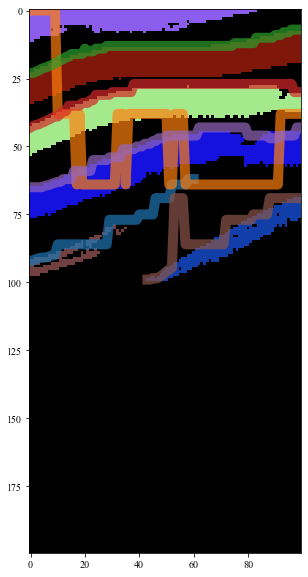

In [144]:
plt.figure(figsize=(20, 10))
plt.imshow(Labels, cmap= colormap, interpolation='none')
for i,traj in enumerate(trajs_pred_):
    t, x = zip(*traj)
    plt.plot(t,x,label = f'pred_{i}', linewidth = 10,alpha = 0.7)
plt.show()

## Simple LSTM

In [5]:
from SimpleLSTM.Models import TrajectoryLSTM


In [108]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Model initialization
hidden_size = 64
num_layers = 2
dropout = 0.2
lane_unit_num = 200
time_span = 100
input_frames = 10
model = TrajectoryLSTM(
    hidden_size=hidden_size,
    num_layers=num_layers,
    dropout = dropout,
)
model.to(device)
model_path = r'D:\TimeSpaceDiagramDataset\SimpleLSTM\Models\train_4\best_model.pth'
model.load_state_dict(torch.load(model_path,weights_only=False)['model_state_dict'])

<All keys matched successfully>

In [113]:
total_tp, total_fp, total_fn = 0, 0, 0
total_switch,total_discontinuity = 0,0
total_speed_errors, total_spatial_errors = [], []
total_occ_speed_errors, total_occ_spatial_errors = [], []
total_occ_acceleration_errors = []
total_acceleration_errors = []
total_recovered_trajs = []
speed_eva_window = 20
x_error_threshold = 2
Iou_threshold = 0.8
time_space_diagram_list = os.listdir(dir_img)
recovered_traj = 0
db = Raster_DBSCAN(Td_map_szie=(lane_unit_num,time_span), window_size=[7,9],eps = 1,min_samples=1)
for frame_ind in tqdm(range(len(time_space_diagram_list))):
    time_space_diagram_name = time_space_diagram_list[frame_ind]
    trajectory_name = trajectory_list[frame_ind]
    time_space_diagram_raw = cv2.imread(os.path.join(dir_img,time_space_diagram_name), cv2.IMREAD_GRAYSCALE)
    traj_type_label,trajs_label = get_traj_labels(traj_dir,trajectory_name,time_space_diagram_raw)
    time_space_diagram_input = time_space_diagram_raw > 100
    time_space_diagram_input = time_space_diagram_input.astype(np.uint8)
    padding = np.zeros((lane_unit_num - time_space_diagram_input.shape[0], time_space_diagram_input.shape[1]))
    time_space_diagram_input = np.concatenate((time_space_diagram_input,padding), axis=0)
    Labels = db.fit_predict(time_space_diagram_input> 0, time_space_diagram_input > 0)
    trajs_pred = get_trajs_from_Kalman_out(Labels)
    trajs_pred_ = []
    for idx in range(len(trajs_pred)):
        traj = trajs_pred[idx][1:]
        traj_ = [traj[:input_frames]]
        start_frame = int(traj[0,0])
        for t in range(input_frames, len(traj)):    
            input_positions = traj[t - input_frames:t, 1]
            input_positions[input_positions< 0] = 0
            input_positions = torch.from_numpy(np.array(input_positions)).unsqueeze(0).to(device).to(torch.float32)
            mask = torch.ones((1, input_frames), dtype=torch.bool).to(device)
            # input_context = time_space_diagram_input[:,t+start_frame - input_frames + 1:t+start_frame + 1]
            # input_context = torch.from_numpy(input_context).unsqueeze(0).permute(0, 2, 1).float().to(device).to(torch.float32)
            with torch.no_grad():
                model.eval()
                predicted_pos = model(input_positions,mask)
                predicted_pos = model(input_positions,mask)[0][0].item()
            predicted_pos = float(predicted_pos)
            traj_.append(np.array([[t+start_frame,predicted_pos]]))
        # break
        trajs_pred_.append(np.concatenate(traj_, axis=0))
    if len(trajs_pred_) == 0:
        total_fn += len(trajs_label)
        continue
    # trajs_label = [traj for i, traj in enumerate(trajs_label) if traj_type_label[i] == 0]
    TrajIoUMatrix,TrajPortionMatrix = get_TrajIoU(trajs_label,trajs_pred_,x_error_threshold = x_error_threshold)
    pred_index = TrajIoUMatrix.argmax(axis = 1)
    pred_IoU = TrajIoUMatrix.max(axis = 1)

    tp,fp,fn,id_switch,discontinuity = get_accuracy_metric(Iou_threshold, TrajIoUMatrix, TrajPortionMatrix, trajs_pred_)
        
    speed_errors,spatial_errors,occ_speed_errors,occ_spatial_errors,acceleration_errors,occ_acceleration_errors = get_speed_spatial_error(trajs_label,trajs_pred,pred_index,pred_IoU,Iou_threshold,speed_eva_window,traj_type_label)
    total_tp += tp
    total_fp += fp
    total_fn += fn
    total_switch += id_switch
    total_discontinuity += discontinuity
    total_speed_errors.append(speed_errors)
    total_spatial_errors.append(spatial_errors)

    trajs_label = [traj for i, traj in enumerate(trajs_label) if traj_type_label[i] == 0] # for only occlusion evaluation
    TrajIoUMatrix,TrajPortionMatrix = get_TrajIoU(trajs_label,trajs_pred,x_error_threshold = x_error_threshold)
    tp,fp,fn,id_switch,discontinuity = get_accuracy_metric(Iou_threshold, TrajIoUMatrix, TrajPortionMatrix, trajs_pred)
    recovered_traj += tp

    total_occ_speed_errors.append(occ_speed_errors)
    total_occ_spatial_errors.append(occ_spatial_errors)
    total_occ_acceleration_errors.append(occ_acceleration_errors)
    total_acceleration_errors.append(acceleration_errors)

100%|██████████| 325/325 [09:25<00:00,  1.74s/it]


In [117]:
total_tp,total_fp,total_fn,total_switch,total_discontinuity,recovered_traj

(1190, 541, 288, 257, 466, 408)